<div style="background: linear-gradient(135deg, #0c1445 0%, #1a237e 50%, #283593 100%); padding: 40px 36px; border-radius: 16px; color: white; font-family: 'Segoe UI', sans-serif; border-left: 6px solid #64b5f6;">
  <div style="font-size: 12px; color: #90caf9; letter-spacing: 3px; text-transform: uppercase; font-weight: 600;">
    SCY1101 — Evaluación Parcial 2 · Notebook 5 de 6
  </div>
  <h1 style="margin: 14px 0 8px; font-size: 32px; font-weight: 700; letter-spacing: -0.5px; color: white;">
    🗺️ Aprendizaje No Supervisado
  </h1>
  <p style="color: #bbdefb; margin: 0 0 24px; font-size: 16px; line-height: 1.6;">
    Sin etiquetas ni targets. Ahora dejamos que los datos hablen solos:<br>
    ¿existen grupos naturales de envíos con comportamientos operativos distintos?
  </p>
  <div style="display: flex; gap: 12px; flex-wrap: wrap;">
    <span style="background: rgba(100,181,246,0.2); color: #90caf9; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(100,181,246,0.3);">🔵 KMeans (k=5)</span>
    <span style="background: rgba(100,181,246,0.2); color: #90caf9; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(100,181,246,0.3);">🔴 DBSCAN</span>
    <span style="background: rgba(100,181,246,0.2); color: #90caf9; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(100,181,246,0.3);">📐 PCA 2D</span>
    <span style="background: rgba(100,181,246,0.2); color: #90caf9; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(100,181,246,0.3);">🧩 Perfil de clusters</span>
  </div>
  <div style="margin-top: 24px; background: rgba(255,255,255,0.07); border-radius: 10px; padding: 12px 18px; font-size: 13px; color: #90caf9;">
    <strong>Progreso del proyecto:</strong>
    <div style="background: rgba(255,255,255,0.15); border-radius: 10px; height: 6px; margin: 8px 0 4px;">
      <div style="background: linear-gradient(90deg, #64b5f6, #90caf9); width: 83%; height: 6px; border-radius: 10px;"></div>
    </div>
    <div style="display: flex; justify-content: space-between; font-size: 11px; color: #bbdefb; opacity: 0.8;">
      <span>✅ EDA</span><span>✅ Modelos</span><span>✅ Evaluación</span><span>✅ Tuning</span><span>▶ Clustering</span><span>Final</span>
    </div>
  </div>
</div>

---

## 🧭 La historia de este notebook

<div style="background: #eff6ff; border-left: 5px solid #3b82f6; padding: 20px 24px; border-radius: 0 12px 12px 0; margin: 16px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1e3a8a; font-size: 15px;">🗺️ Explorar lo que no sabíamos que existía</strong><br><br>
  <span style="color: #1e40af; font-size: 14px; line-height: 1.7;">
    Los modelos supervisados respondieron preguntas específicas con etiquetas conocidas.
    El aprendizaje no supervisado hace algo distinto: <strong>no tiene target</strong>.
    No le decimos al algoritmo qué buscar — le dejamos encontrar patrones por sí solo.<br><br>
    La pregunta aquí es: ¿existen grupos naturales de envíos con características operativas similares?
    Un cluster de envíos cortos y ligeros debería comportarse distinto a uno de envíos pesados y de larga distancia.
    Si esos grupos existen, el negocio puede diseñar estrategias diferenciadas para cada segmento.
  </span>
</div>

**Tres algoritmos, tres perspectivas:**

| Algoritmo | Enfoque | Resultado esperado |
|-----------|---------|-------------------|
| `KMeans` | Divide en K grupos minimizando distancia interna | Clusters bien definidos si k es correcto |
| `DBSCAN` | Agrupa por densidad, marca outliers como ruido | Útil para detectar anomalías operativas |
| `PCA` | Reduce dimensiones para visualizar en 2D | Mapa visual de la distribución de envíos |

> **Advertencia honesta:** si los clusters tienen silhouette bajo, no significa que el análisis falló. Significa que los datos no tienen agrupaciones naturales fuertes — eso también es un hallazgo válido y defendible.

In [1]:
from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_MODEL = PROJECT_ROOT / "data" / "05_model_input"
DATA_OUTPUT = PROJECT_ROOT / "data" / "07_model_output"
DATA_REPORT = PROJECT_ROOT / "data" / "08_reporting"
DATA_MODELS = PROJECT_ROOT / "data" / "06_models"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)


def read_csv(path):
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


def clean_text_columns(df):
    df = df.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.replace("Ã³", "o", regex=False)
    return df


---

## 1. 📂 Cargar salidas de clustering

<div style="background: #fefce8; border-left: 5px solid #eab308; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Qué contienen estas tablas?</strong><br>
  <span style="font-size: 13px; color: #713f12;">
    El pipeline <code>unsupervised_learning</code> de Kedro ejecutó KMeans, DBSCAN y PCA,
    y guardó: el perfil de cada cluster (promedios por variable), las métricas de calidad del clustering,
    y las coordenadas PCA de cada envío para visualización.
  </span>
</div>

In [2]:
perfil_clusters = read_csv(DATA_OUTPUT / "perfil_clusters.csv")
metricas_clustering = read_csv(DATA_OUTPUT / "metricas_clustering.csv")
clusters_pca = read_csv(DATA_OUTPUT / "clusters_pca.csv")

display(metricas_clustering)
display(perfil_clusters)


,metodo,parametros,n_clusters,n_ruido,silhouette_score,davies_bouldin_score,inertia,varianza_explicada
0,KMeans,k=3,3,0.0,0.0815,2.7464,16065.4070,NaN
1,KMeans,k=4,4,0.0,0.0792,2.6310,15231.2016,NaN
2,KMeans,k=5,5,0.0,0.0816,2.5133,14667.2292,NaN
3,DBSCAN,"eps=2.5, min_samples=10",0,866.0,NaN,NaN,NaN,NaN
4,PCA,n_components=2,5,NaN,NaN,NaN,NaN,0.2008


,cluster,n_envios,tasa_incidencia,peso_kg_promedio,distancia_km_promedio,tiempo_estimado_hrs_promedio,peaje_total_promedio,eficiencia_peso_promedio,interpretacion_negocio
0,0,30,0.1667,6615.2500,30.2933,6.4067,11412.2000,1.4893,riesgo_operativo_medio
1,1,63,0.1587,8573.0460,1027.1492,12.3397,5960.8889,6.4712,riesgo_operativo_medio
2,2,143,0.1748,7885.5021,947.3811,12.3469,6899.2867,0.5826,riesgo_operativo_medio
3,3,286,0.1503,6994.3621,1040.7108,12.7413,6632.6014,1.2045,riesgo_operativo_medio
4,4,344,0.1831,6591.7406,953.8172,12.1340,7018.1221,1.2283,riesgo_operativo_medio


---

## 2. 📐 Mapa PCA — envíos en 2 dimensiones

<div style="background: #eff6ff; border-left: 5px solid #3b82f6; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Qué hace PCA aquí?</strong><br>
  <span style="font-size: 13px; color: #1e3a8a;">
    PCA (Análisis de Componentes Principales) comprime las 26 variables del dataset ML
    en 2 dimensiones para poder visualizarlos en un plano. Las 2 dimensiones capturan el
    <strong>~20% de la varianza total</strong> — no es toda la información, pero permite ver
    si los clusters de KMeans tienen separación visual.
  </span>
</div>

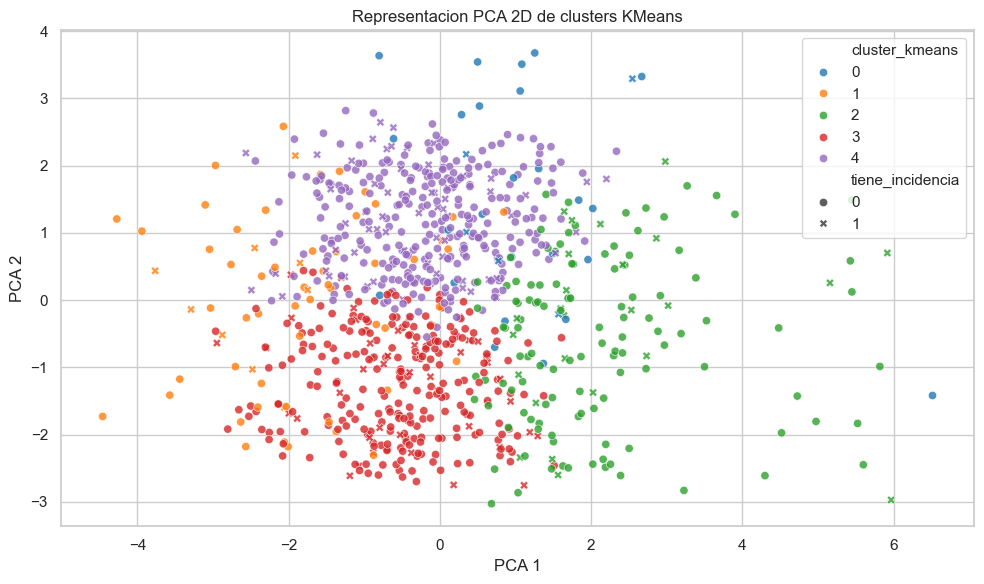

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clusters_pca,
    x="pca_1",
    y="pca_2",
    hue="cluster_kmeans",
    style="tiene_incidencia",
    palette="tab10",
    alpha=0.8,
)
plt.title("Representacion PCA 2D de clusters KMeans")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()


<div style="background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1e40af;">📊 Cómo leer el mapa PCA</strong><br><br>
  <span style="color: #1e3a8a; font-size: 14px; line-height: 1.7;">
    Cada punto es un envío. Los colores representan los clusters asignados por KMeans.
    La forma del punto indica si DBSCAN lo marcó como ruido (triángulo) o no (círculo).<br><br>
    <strong>Varianza explicada ≈ 20%:</strong> Las dos dimensiones del mapa capturan solo el 20%
    de la información original. Por eso la separación visual puede parecer borrosa aunque KMeans
    haya encontrado agrupaciones en el espacio completo de 26 dimensiones.<br><br>
    <strong>Lo que buscamos:</strong> ¿se ven grupos de colores concentrados o todo está mezclado?
    Una mezcla indica que los clusters son exploratorios, no definitivos.
  </span>
</div>

---

## 3. 🧩 Perfil de los clusters — ¿qué tipo de envío es cada uno?

<div style="background: #f0fdf4; border-left: 5px solid #22c55e; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Para qué sirve perfilar los clusters?</strong><br>
  <span style="font-size: 13px; color: #14532d;">
    Un cluster sin nombre no tiene valor de negocio. El perfil le da identidad a cada grupo:
    ¿es el cluster de envíos pesados y cortos? ¿el de larga distancia con alta tasa de incidencia?
    ¿el de carga ligera y rápida? Con esa descripción, el equipo de operaciones puede tomar decisiones diferenciadas.
  </span>
</div>

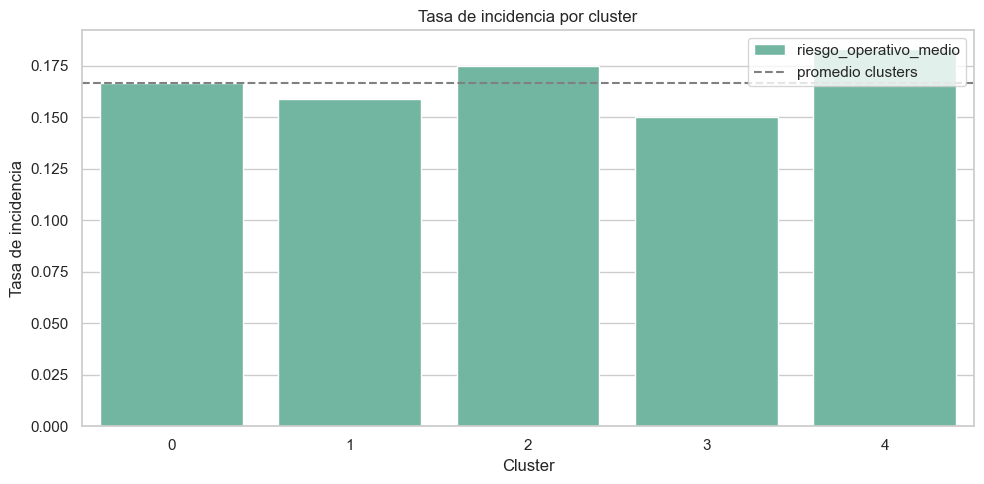

,cluster,n_envios,tasa_incidencia,peso_kg_promedio,distancia_km_promedio,tiempo_estimado_hrs_promedio,peaje_total_promedio,eficiencia_peso_promedio,interpretacion_negocio
0,0,30,0.1667,6615.2500,30.2933,6.4067,11412.2000,1.4893,riesgo_operativo_medio
1,1,63,0.1587,8573.0460,1027.1492,12.3397,5960.8889,6.4712,riesgo_operativo_medio
2,2,143,0.1748,7885.5021,947.3811,12.3469,6899.2867,0.5826,riesgo_operativo_medio
3,3,286,0.1503,6994.3621,1040.7108,12.7413,6632.6014,1.2045,riesgo_operativo_medio
4,4,344,0.1831,6591.7406,953.8172,12.1340,7018.1221,1.2283,riesgo_operativo_medio


In [4]:
cols_perfil = [c for c in perfil_clusters.columns if c not in ["cluster", "interpretacion_negocio"]]
perfil_largo = perfil_clusters.melt(
    id_vars=["cluster", "interpretacion_negocio"],
    value_vars=cols_perfil,
    var_name="variable",
    value_name="valor",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=perfil_clusters, x="cluster", y="tasa_incidencia", hue="interpretacion_negocio")
plt.axhline(perfil_clusters["tasa_incidencia"].mean(), color="gray", linestyle="--", label="promedio clusters")
plt.title("Tasa de incidencia por cluster")
plt.xlabel("Cluster")
plt.ylabel("Tasa de incidencia")
plt.legend()
plt.tight_layout()
plt.show()

display(perfil_clusters)


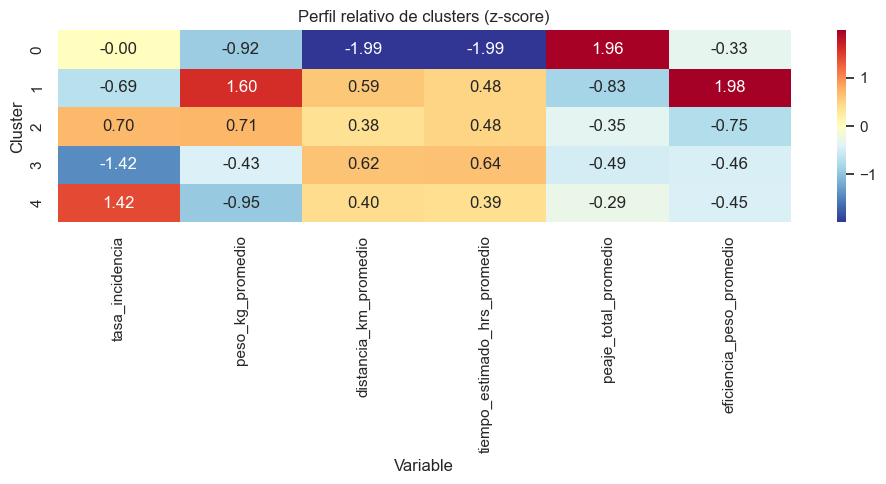

In [5]:
heat_cols = [
    "tasa_incidencia", "peso_kg_promedio", "distancia_km_promedio",
    "tiempo_estimado_hrs_promedio", "peaje_total_promedio",
    "eficiencia_peso_promedio"
]
heat_cols = [c for c in heat_cols if c in perfil_clusters.columns]
perfil_heat = perfil_clusters.set_index("cluster")[heat_cols]
perfil_norm = (perfil_heat - perfil_heat.mean()) / perfil_heat.std(ddof=0)

plt.figure(figsize=(10, 5))
sns.heatmap(perfil_norm, annot=True, cmap="RdYlBu_r", center=0, fmt=".2f")
plt.title("Perfil relativo de clusters (z-score)")
plt.xlabel("Variable")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


<div style="background: #f0fdf4; border: 1px solid #bbf7d0; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #166534;">🧩 Cómo leer el perfil de clusters</strong><br><br>
  <span style="color: #14532d; font-size: 14px; line-height: 1.7;">
    El heatmap muestra el valor promedio de cada variable por cluster — colores más intensos indican valores más altos.<br><br>
    <strong>La columna clave es <code>tasa_incidencia</code>:</strong> si un cluster tiene tasa alta,
    esos envíos son candidatos prioritarios de monitoreo operativo.
    Combinado con <code>peso_kg</code> y <code>distancia_km</code>, se puede construir un perfil de riesgo
    por segmento operativo sin necesidad de un modelo supervisado.
  </span>
</div>

---

## 4. 📊 Métricas de clustering — ¿qué tan bien funcionó KMeans?

<div style="background: #fdf4ff; border-left: 5px solid #a855f7; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>El silhouette score — la vara de medición</strong><br>
  <span style="font-size: 13px; color: #581c87;">
    El silhouette mide qué tan compactos son los clusters internamente y qué tan separados están entre sí.
    Va de -1 (mal clustering) a +1 (clustering perfecto).
    El <strong>silhouette de KMeans con k=5 = 0.082</strong> indica clusters exploratorios, no segmentaciones definitivas.
    DBSCAN con los parámetros actuales marcó todos los registros como ruido.
  </span>
</div>

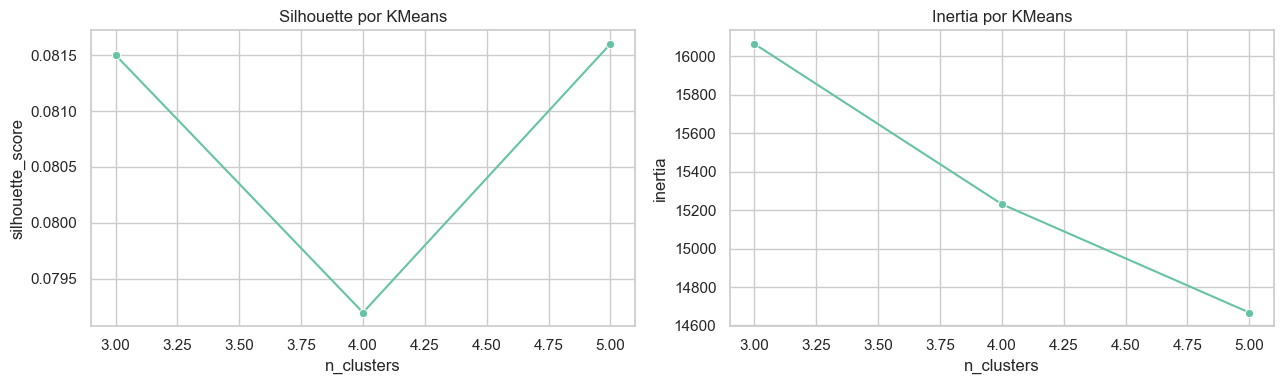

In [6]:
km = metricas_clustering[metricas_clustering["metodo"] == "KMeans"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=km, x="n_clusters", y="silhouette_score", marker="o", ax=axes[0])
axes[0].set_title("Silhouette por KMeans")
sns.lineplot(data=km, x="n_clusters", y="inertia", marker="o", ax=axes[1])
axes[1].set_title("Inertia por KMeans")
plt.tight_layout()
plt.show()


<div style="background: #fff1f2; border: 1px solid #fecdd3; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #881337;">⚠️ DBSCAN marcó todo como ruido — ¿fracasó el análisis? No</strong><br><br>
  <span style="color: #9f1239; font-size: 14px; line-height: 1.7;">
    DBSCAN con <code>eps=2.5</code> clasificó todos los registros como ruido (clase -1).
    Esto ocurre cuando los datos no tienen densidad local suficiente para formar núcleos con los parámetros elegidos.<br><br>
    <strong>Lo que esto dice sobre los datos:</strong> los envíos no se concentran en zonas densas del espacio de variables —
    están distribuidos de forma relativamente uniforme. Eso es un hallazgo informativo, no un error.<br><br>
    <strong>Para la defensa:</strong> "DBSCAN con los parámetros actuales no encontró clusters densos.
    Esto indica que los envíos son heterogéneos entre sí. Se documenta como técnica exploratoria
    que requeriría ajuste de parámetros con más datos operativos."
  </span>
</div>

---

## 🏁 Conclusión: segmentación exploratoria completada

<div style="background: linear-gradient(135deg, #0c1445 0%, #1a237e 50%, #283593 100%); padding: 28px 32px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif; margin: 16px 0;">
  <h3 style="margin: 0 0 16px; color: #90caf9;">📋 Resumen del aprendizaje no supervisado</h3>
  <div style="display: flex; gap: 16px; flex-wrap: wrap; margin-bottom: 20px;">
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 26px; font-weight: bold; color: #60a5fa;">k=5</div>
      <div style="font-size: 12px; color: #bbdefb; margin-top: 4px;">Mejor configuración KMeans</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 26px; font-weight: bold; color: #fbbf24;">0.082</div>
      <div style="font-size: 12px; color: #bbdefb; margin-top: 4px;">Silhouette — clusters exploratorios</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 26px; font-weight: bold; color: #f87171;">100%</div>
      <div style="font-size: 12px; color: #bbdefb; margin-top: 4px;">DBSCAN → ruido (limitación documentada)</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 26px; font-weight: bold; color: #4ade80;">~20%</div>
      <div style="font-size: 12px; color: #bbdefb; margin-top: 4px;">Varianza explicada por PCA 2D</div>
    </div>
  </div>
  <p style="color: #bbdefb; margin: 0; font-size: 14px; line-height: 1.7;">
    KMeans identifica 5 segmentos operativos exploratorios con distintas características de peso, distancia y tasa de incidencia.
    No son segmentos definitivos, pero permiten diseñar estrategias diferenciadas por tipo de envío.
    DBSCAN y PCA complementan el análisis con perspectivas de densidad y visualización.
  </p>
</div>

<div style="background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 16px 20px; margin-top: 16px; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1e40af;">➡️ Siguiente: Notebook 06 — Análisis Final y Defensa</strong><br>
  <span style="color: #1e3a8a; font-size: 14px;">
    El último notebook consolida todo el proyecto: KPIs finales, recomendaciones de negocio,
    checklist de cumplimiento y el guion completo para la defensa individual.
  </span>
</div>